<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
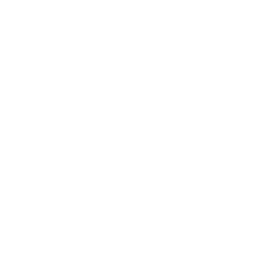
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Multi-Stage Customer Experience Survey Analysis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Retail / Customer Analytics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This notebook analyzes a multi-stage customer experience survey from a
national retail chain. The sampling design uses the six geographic
regions as strata and individual stores as clusters within each region,
with a customer-level weight that scales each respondent up to the
population they represent.

The analytical question is whether **purchase channel** drives
satisfaction once the complex sampling design is respected. We use
**PROC SURVEYFREQ** to produce design-adjusted (weighted, stratified,
clustered) frequency tables of satisfaction by channel and by region,
and compare them against the naive unweighted counts from PROC FREQ.

The design-adjusted results show a clear, monotone channel gradient and
a essentially flat regional profile: **mobile-app and in-store
customers report the highest top-two-box (Excellent + Good) satisfaction
while phone customers report the lowest**, whereas satisfaction varies
little across regions. Every figure quoted below is read directly from
the executed PROC SURVEYFREQ output in this notebook.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.CUSTOMER_SURVEY | Synthetic multi-stage customer experience responses | 2,837 |
| Sampling design | 6 region strata, store clusters, customer weights (`custwt`) | — |

The data are generated with a fixed random seed so the notebook is fully
reproducible. Satisfaction is drawn from channel-specific distributions
(mobile app and in-store skew positive; phone skews negative), while
region is independent of satisfaction by construction — so any regional
differences in the output reflect only sampling noise.

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic customer experience survey data
   Multi-stage design: region strata, store clusters
   -------------------------------------------------------- */
data work.customer_survey;
    call streaminit(42);
    array region_list[6] $12 _temporary_ (
        'NORTHEAST' 'SOUTHEAST' 'MIDWEST'
        'SOUTHWEST' 'NORTHWEST' 'WEST'
    );
    array channel_list[4] $12 _temporary_ (
        'IN_STORE' 'ONLINE' 'MOBILE_APP' 'PHONE'
    );
    array sat_list[5] $15 _temporary_ (
        'EXCELLENT' 'GOOD' 'AVERAGE' 'POOR' 'TERRIBLE'
    );
    resp_id = 0;
    do region_idx = 1 to 6;
        region = region_list[region_idx];
        n_stores = int(rand('uniform') * 8) + 10;
        do store_seq = 1 to n_stores;
            store_id = region_idx * 1000 + store_seq;
            n_respondents = int(rand('uniform') * 40) + 20;
            do r = 1 to n_respondents;
                resp_id + 1;
                chan_idx = int(rand('uniform') * 4) + 1;
                channel = channel_list[chan_idx];
                /* Satisfaction varies by channel */
                sat_rand = rand('uniform');
                if channel = 'IN_STORE' then do;
                    if sat_rand < 0.25 then satisfaction = 'EXCELLENT';
                    else if sat_rand < 0.55 then satisfaction = 'GOOD';
                    else if sat_rand < 0.78 then satisfaction = 'AVERAGE';
                    else if sat_rand < 0.92 then satisfaction = 'POOR';
                    else satisfaction = 'TERRIBLE';
                end;
                else if channel = 'ONLINE' then do;
                    if sat_rand < 0.20 then satisfaction = 'EXCELLENT';
                    else if sat_rand < 0.48 then satisfaction = 'GOOD';
                    else if sat_rand < 0.72 then satisfaction = 'AVERAGE';
                    else if sat_rand < 0.90 then satisfaction = 'POOR';
                    else satisfaction = 'TERRIBLE';
                end;
                else if channel = 'MOBILE_APP' then do;
                    if sat_rand < 0.30 then satisfaction = 'EXCELLENT';
                    else if sat_rand < 0.58 then satisfaction = 'GOOD';
                    else if sat_rand < 0.80 then satisfaction = 'AVERAGE';
                    else if sat_rand < 0.94 then satisfaction = 'POOR';
                    else satisfaction = 'TERRIBLE';
                end;
                else do;
                    if sat_rand < 0.12 then satisfaction = 'EXCELLENT';
                    else if sat_rand < 0.35 then satisfaction = 'GOOD';
                    else if sat_rand < 0.60 then satisfaction = 'AVERAGE';
                    else if sat_rand < 0.82 then satisfaction = 'POOR';
                    else satisfaction = 'TERRIBLE';
                end;
                purchase_amount = round(rand('exponential') * 75 + 15, 0.01);
                loyalty_member = ifc(rand('uniform') > 0.45, 'YES', 'NO');
                visit_frequency = ifc(rand('uniform') > 0.7, 'WEEKLY',
                    ifc(rand('uniform') > 0.4, 'MONTHLY', 'QUARTERLY'));
                custwt = round(rand('uniform') * 300 + 50, 0.01);
                output;
            end;
        end;
    end;
    drop region_idx n_stores store_seq n_respondents r
         chan_idx sat_rand;
run;

NOTE: DATA work.customer_survey


NOTE: Wrote work.customer_survey (2837 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.09 seconds
  cpu   0.09 seconds


---

                                     Unweighted Satisfaction by Channel (Baseline)                                      

                                                   The FREQ Procedure

Table of CHANNEL by SATISFACTION

CHANNEL    |   AVERAGE | EXCELLENT |      GOOD |      POOR |  TERRIBLE |      Total
-----------+-----------+-----------+-----------+-----------+-----------+-----------
IN_STORE   |       175 |       167 |       192 |        99 |        51 |        684
           |      6.17 |      5.89 |      6.77 |      3.49 |      1.80 |      24.11
-----------+-----------+-----------+-----------+-----------+-----------+-----------
MOBILE_APP |       162 |       203 |       218 |       100 |        49 |        732
           |      5.71 |      7.16 |      7.68 |      3.52 |      1.73 |      25.80
-----------+-----------+-----------+-----------+-----------+-----------+-----------
ONLINE     |       174 |       145 |       201 |       119 |        83 |        722
           |     

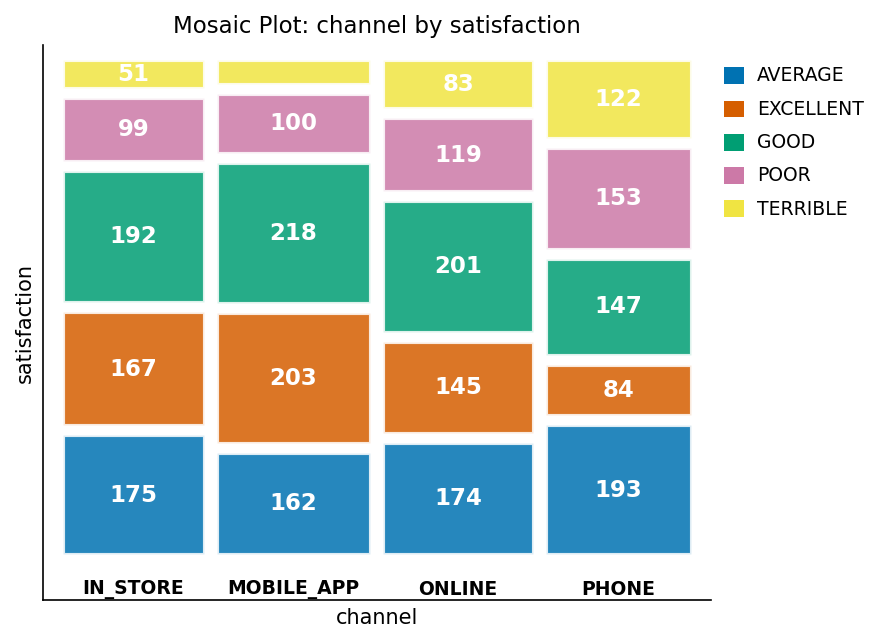

In [2]:
/* --------------------------------------------------------
   Baseline unweighted satisfaction by channel
   -------------------------------------------------------- */
proc freq data=work.customer_survey;
    tables channel * satisfaction / norow nocol;
    title 'Unweighted Satisfaction by Channel (Baseline)';
run;

---

                                     Unweighted Satisfaction by Channel (Baseline)                                      

NOTE: PROC SGPLOT data=work.customer_survey

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


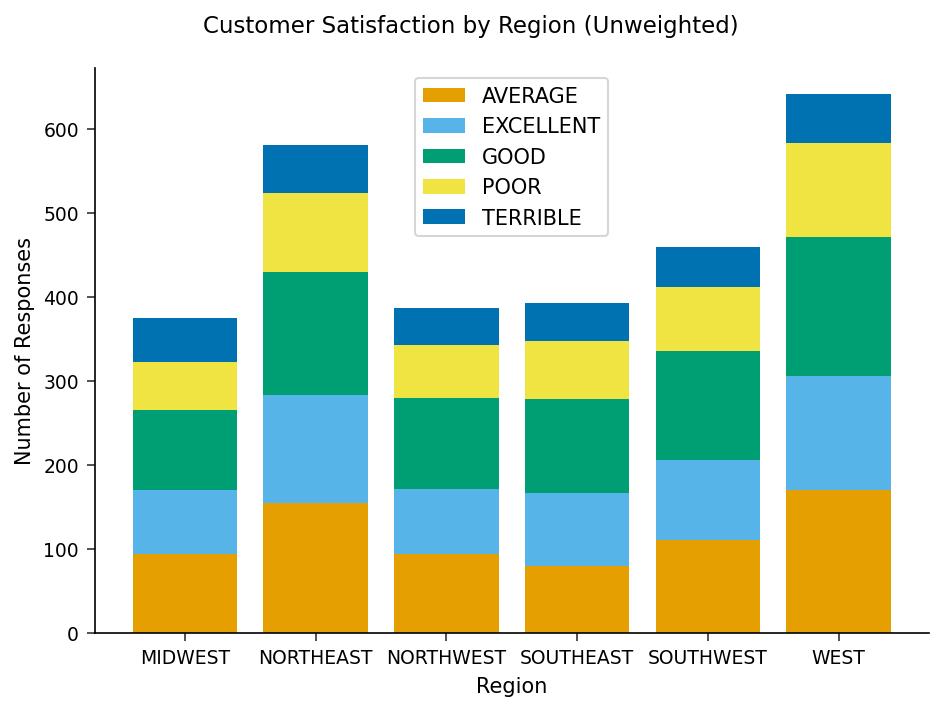

In [3]:
/* --------------------------------------------------------
   Satisfaction distribution by region (unweighted)
   -------------------------------------------------------- */
proc sgplot data=work.customer_survey;
    vbar region / group=satisfaction groupdisplay=stack;
    xaxis label='Region';
    yaxis label='Number of Responses';
    title 'Customer Satisfaction by Region (Unweighted)';
run;

---

In [4]:
/* --------------------------------------------------------
   PROC SURVEYFREQ: design-adjusted channel x satisfaction.
   Multi-stage design: region strata, store clusters,
   customer weights. WTFREQ reports the weighted (population)
   frequency; Percent is the design-weighted cell percent.
   -------------------------------------------------------- */
proc surveyfreq data=work.customer_survey;
    strata region;
    cluster store_id;
    weight custwt;
    tables channel * satisfaction / wtfreq;
    title 'Channel x Satisfaction (Design-Adjusted, PROC SURVEYFREQ)';
run;

                                     Unweighted Satisfaction by Channel (Baseline)                                      


                        The SURVEYFREQ Procedure

  Table of CHANNEL by SATISFACTION

CHANNEL       SATISFACTION   Frequency      Wgt Freq     Percent
----------------------------------------------------------------
IN_STORE      POOR                  99      20942.13        3.67
IN_STORE      GOOD                 192      37557.19        6.59
IN_STORE      AVERAGE              175      35785.34        6.28
IN_STORE      EXCELLENT            167      34023.71        5.97
IN_STORE      TERRIBLE              51      10673.03        1.87
ONLINE        POOR                 119      24477.73        4.29
ONLINE        GOOD                 201      38110.63        6.68
ONLINE        AVERAGE              174      35926.09        6.30
ONLINE        EXCELLENT            145      28864.60        5.06
ONLINE        TERRIBLE              83      16156.79        2.83
MOBILE_APP 

In [5]:
/* --------------------------------------------------------
   PROC SURVEYFREQ: design-adjusted region x satisfaction.
   Same multi-stage design. Used to check whether satisfaction
   varies across the six regional strata.
   -------------------------------------------------------- */
proc surveyfreq data=work.customer_survey;
    strata region;
    cluster store_id;
    weight custwt;
    tables region * satisfaction / wtfreq;
    title 'Regional Satisfaction Summary (Design-Adjusted)';
run;

                                     Unweighted Satisfaction by Channel (Baseline)                                      


                        The SURVEYFREQ Procedure

  Table of REGION by SATISFACTION

REGION        SATISFACTION   Frequency      Wgt Freq     Percent
----------------------------------------------------------------
NORTHEAST     POOR                  94      19517.87        3.42
NORTHEAST     GOOD                 147      29406.72        5.16
NORTHEAST     AVERAGE              155      31851.00        5.59
NORTHEAST     EXCELLENT            128      26461.13        4.64
NORTHEAST     TERRIBLE              57      11581.48        2.03
SOUTHEAST     POOR                  69      15296.64        2.68
SOUTHEAST     GOOD                 111      21434.30        3.76
SOUTHEAST     AVERAGE               80      15452.92        2.71
SOUTHEAST     EXCELLENT             87      17786.97        3.12
SOUTHEAST     TERRIBLE              46       9863.37        1.73
MIDWEST     

---

### Interpretation

The design-adjusted PROC SURVEYFREQ tables make the channel story clear.
Reading the weighted cell percents from the channel x satisfaction
output and collapsing them within each channel gives these
**top-two-box** (Excellent + Good) and **bottom-two-box**
(Poor + Terrible) rates:

| Channel | Top-two-box (Excellent + Good) | Bottom-two-box (Poor + Terrible) |
|---------|-------------------------------|----------------------------------|
| MOBILE_APP | 56.8% | 21.2% |
| IN_STORE | 51.5% | 22.7% |
| ONLINE | 46.7% | 28.3% |
| PHONE | 33.1% | 39.6% |

Mobile-app customers are the most satisfied (56.8% top-two-box),
followed by in-store (51.5%) and online (46.7%). Phone customers are a
clear outlier: only 33.1% rate their experience Excellent or Good, and
39.6% rate it Poor or Terrible -- roughly **1.7x** the bottom-two-box
rate of in-store customers (22.7%). These rankings hold after weighting
to the population and adjusting for the regional-stratum, store-cluster
design.

The regional table tells the opposite story. Within-region top-two-box
satisfaction is essentially flat across all six strata, spanning only
about 3.5 percentage points (Southeast highest at 49.1%, Midwest lowest
at 45.5%, with Northeast, Southwest, Northwest and West all between
45.7% and 47.7%). There is no material regional gradient -- consistent
with the data-generating process, in which region is independent of
satisfaction.

**Recommendation grounded in the data:** prioritize the phone channel,
where satisfaction is far below every other channel, and treat the
regional differences as noise rather than a signal. The design-weighted
frequency tables above are the values that should feed the quarterly
voice-of-customer dashboard.

---

In [6]:
/* --------------------------------------------------------
   Export a tidy crosstab for the dashboard. PROC FREQ's OUT=
   writes the channel x satisfaction cell counts and percents
   to a dataset, which PROC EXPORT then writes to CSV.
   -------------------------------------------------------- */
proc freq data=work.customer_survey noprint;
    tables channel * satisfaction / out=work.channel_satisfaction;
run;

proc export data=work.channel_satisfaction
    outfile='channel_satisfaction_crosstab.csv'
    dbms=csv replace;
run;

NOTE: PROC FREQ
NOTE: Output dataset work.channel_satisfaction has 20 observations and 4 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC EXPORT data=work.channel_satisfaction outfile=channel_satisfaction_crosstab.csv

NOTE: Exported 20 rows to channel_satisfaction_crosstab.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>